# Day 15: Working with Image Data

> **Goal:** Understand how images are represented as tensors, explore CIFAR-10, and master data augmentation.

---

## Images as Tensors

As an optical engineer, you're very familiar with images. Here's how deep learning sees them:

| Property | Description |
|---|---|
| **Grayscale** | 1 channel: `(1, H, W)` — like a single-wavelength sensor |
| **RGB** | 3 channels: `(3, H, W)` — Red, Green, Blue |
| **Pixel values** | Typically [0, 255] integers → normalised to [0, 1] floats |
| **PyTorch format** | `(B, C, H, W)` — Batch, Channels, Height, Width |
| **NumPy/OpenCV** | `(H, W, C)` — different ordering! |

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

---
## 1. CIFAR-10 — A Real RGB Dataset

CIFAR-10 has 60,000 colour images (32×32 pixels) in 10 classes:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`

This is **much harder** than MNIST — colour, complex shapes, backgrounds.

In [3]:
# Load CIFAR-10 without augmentation first (just ToTensor for visualization)
basic_transform = transforms.ToTensor()

cifar_train = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=basic_transform
)
cifar_test = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=basic_transform
)

classes = cifar_train.classes
print(f"Training samples: {len(cifar_train)}")
print(f"Test samples:     {len(cifar_test)}")
print(f"Classes:          {classes}")
print(f"Image shape:      {cifar_train[0][0].shape}")  # (3, 32, 32)

100%|██████████| 170M/170M [04:05<00:00, 695kB/s] 


Training samples: 50000
Test samples:     10000
Classes:          ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape:      torch.Size([3, 32, 32])


### Exploring CIFAR-10 Images

Below we visualize one sample from each class, then decompose an image into its R/G/B channels. Each color channel is essentially a grayscale image showing that color's intensity. Think of it like separating a color photograph into three monochrome sensor readings.

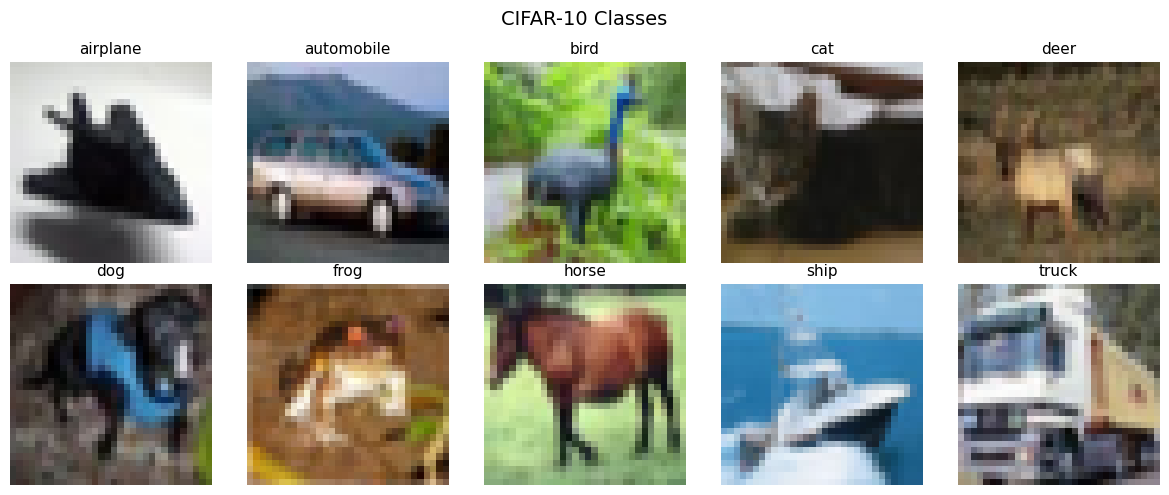

In [4]:
# Visualize samples from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_idx, ax in enumerate(axes.flat):
    # Find first image of this class
    for img, label in cifar_train:
        if label == class_idx:
            # PyTorch tensor (C,H,W) → NumPy (H,W,C) for matplotlib
            ax.imshow(img.permute(1, 2, 0))
            ax.set_title(classes[class_idx], fontsize=11)
            ax.axis("off")
            break

plt.suptitle("CIFAR-10 Classes", fontsize=14)
plt.tight_layout()
plt.show()

Image shape: torch.Size([3, 32, 32])
Data type:   torch.float32
Value range: [0.000, 1.000]


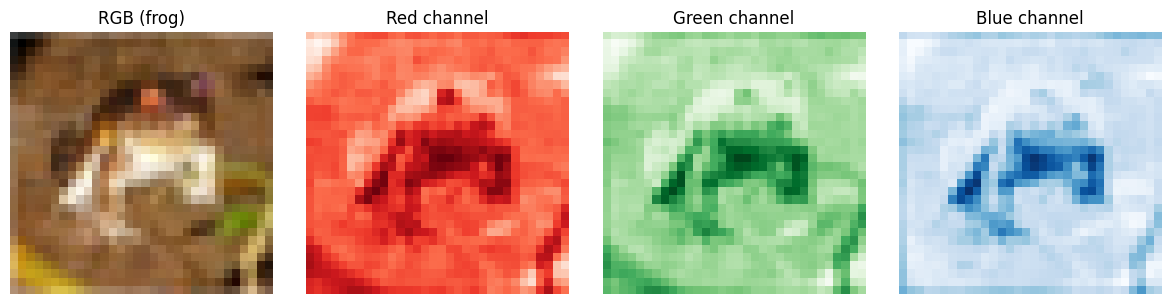

In [5]:
# Understanding RGB channels
img, label = cifar_train[0]
print(f"Image shape: {img.shape}")
print(f"Data type:   {img.dtype}")
print(f"Value range: [{img.min():.3f}, {img.max():.3f}]")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(img.permute(1, 2, 0))
axes[0].set_title(f"RGB ({classes[label]})")

channel_names = ["Red", "Green", "Blue"]
cmaps = ["Reds", "Greens", "Blues"]
for i in range(3):
    axes[i+1].imshow(img[i], cmap=cmaps[i])
    axes[i+1].set_title(f"{channel_names[i]} channel")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 2. Data Augmentation — Why & How

**Data augmentation** applies random transformations to training images, effectively creating "new" training data.

### Why it helps
- The model sees slightly different versions each epoch → less overfitting
- Teaches the model **invariance** (e.g., a cat is still a cat when flipped)
- Free extra data!

### Common augmentations
| Transform | What it does |
|---|---|
| `RandomHorizontalFlip` | Flip left-right with 50% probability |
| `RandomCrop` | Crop a random region (with optional padding) |
| `RandomRotation` | Rotate by a random angle |
| `ColorJitter` | Randomly change brightness, contrast, saturation, hue |
| `RandomResizedCrop` | Crop + resize to original size |
| `RandomErasing` | Randomly erase a rectangle (like dropout for pixels) |

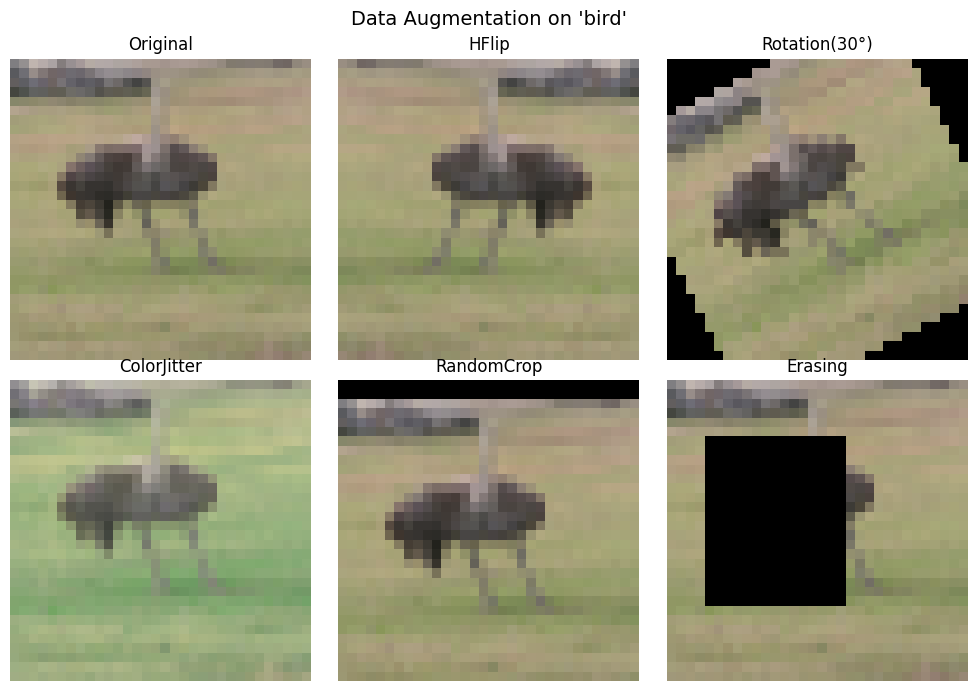

In [6]:
# Visualize augmentations on a single image
img, label = cifar_train[42]

augmentations = {
    "Original": transforms.Compose([]),
    "HFlip": transforms.RandomHorizontalFlip(p=1.0),
    "Rotation(30°)": transforms.RandomRotation(30),
    "ColorJitter": transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1),
    "RandomCrop": transforms.Compose([
        transforms.Pad(4),
        transforms.RandomCrop(32),
    ]),
    "Erasing": transforms.Compose([
        transforms.RandomErasing(p=1.0, scale=(0.1, 0.3)),
    ]),
}

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, (name, aug) in zip(axes.flat, augmentations.items()):
    augmented = aug(img)
    ax.imshow(augmented.permute(1, 2, 0).clamp(0, 1))
    ax.set_title(name)
    ax.axis("off")
plt.suptitle(f"Data Augmentation on '{classes[label]}'", fontsize=14)
plt.tight_layout()
plt.show()

### Seeing Augmentation Variety

The second visualization below shows the **same image** augmented 10 different times. Each epoch during training, the model sees a slightly different version — this diversity helps prevent memorization and encourages the model to focus on the essential features of each class.

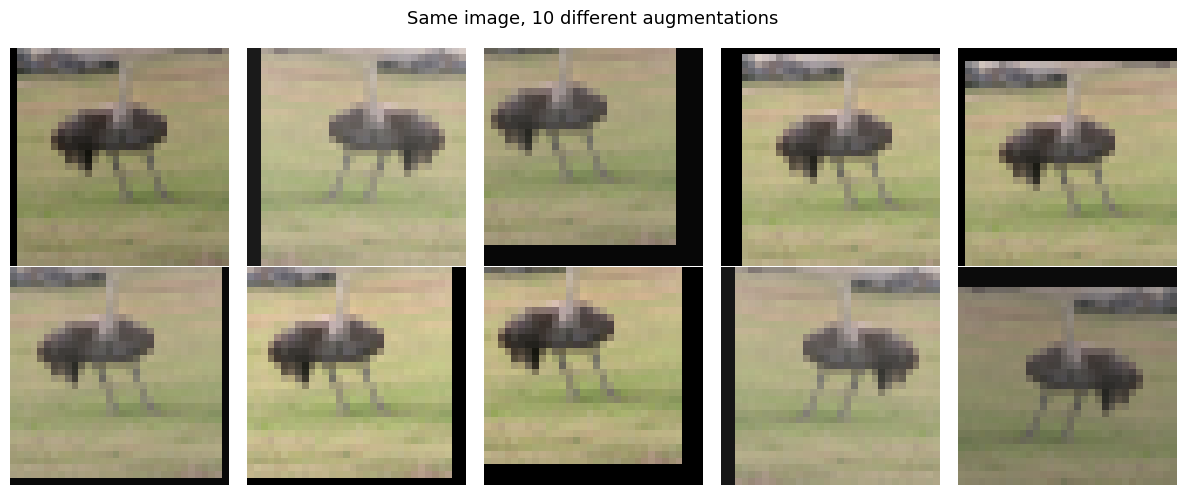

In [7]:
# Show the same image augmented multiple times
train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Same image, 10 different augmentations", fontsize=13)
for ax in axes.flat:
    augmented = train_aug(img)
    ax.imshow(augmented.permute(1, 2, 0).clamp(0, 1))
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 3. Standard CIFAR-10 Transform Pipelines

**Key rule:** Augment training data only! Test data gets only normalization.

In [9]:
# CIFAR-10 mean and std (precomputed)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Training transform: augment + normalize
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Test transform: only normalize (NO augmentation!)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Reload with proper transforms
train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True,
                                              download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root="./data", train=False,
                                              download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

# Check a batch
imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}")
print(f"Pixel range (after norm): [{imgs.min():.2f}, {imgs.max():.2f}]")

print(f"Training samples: {len(train_loader)}")
print(f"Test samples:     {len(test_loader)}")

Batch shape: torch.Size([128, 3, 32, 32])
Pixel range (after norm): [-1.99, 2.13]
Training samples: 391
Test samples:     79


---
## 4. Computing Dataset Statistics

Where do those mean and std values come from? You can compute them yourself.

In [10]:
# Compute mean and std of CIFAR-10
raw_data = torchvision.datasets.CIFAR10(root="./data", train=True,
                                         download=True, transform=transforms.ToTensor())
loader = DataLoader(raw_data, batch_size=1024, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
n_pixels = 0

for imgs, _ in loader:
    b, c, h, w = imgs.shape
    n = b * h * w
    mean += imgs.sum(dim=[0, 2, 3])
    n_pixels += n

mean /= n_pixels

for imgs, _ in loader:
    b, c, h, w = imgs.shape
    std += ((imgs - mean[None, :, None, None]) ** 2).sum(dim=[0, 2, 3])

std = (std / n_pixels).sqrt()

print(f"Computed mean: {mean.tolist()}")
print(f"Computed std:  {std.tolist()}")
print(f"\nStandard values:")
print(f"  mean: {list(CIFAR_MEAN)}")
print(f"  std:  {list(CIFAR_STD)}")

Computed mean: [0.4913996160030365, 0.482158362865448, 0.44653090834617615]
Computed std:  [0.24703224003314972, 0.24348513782024384, 0.26158782839775085]

Standard values:
  mean: [0.4914, 0.4822, 0.4465]
  std:  [0.247, 0.2435, 0.2616]


---
## 5. Helper: Unnormalize for Display

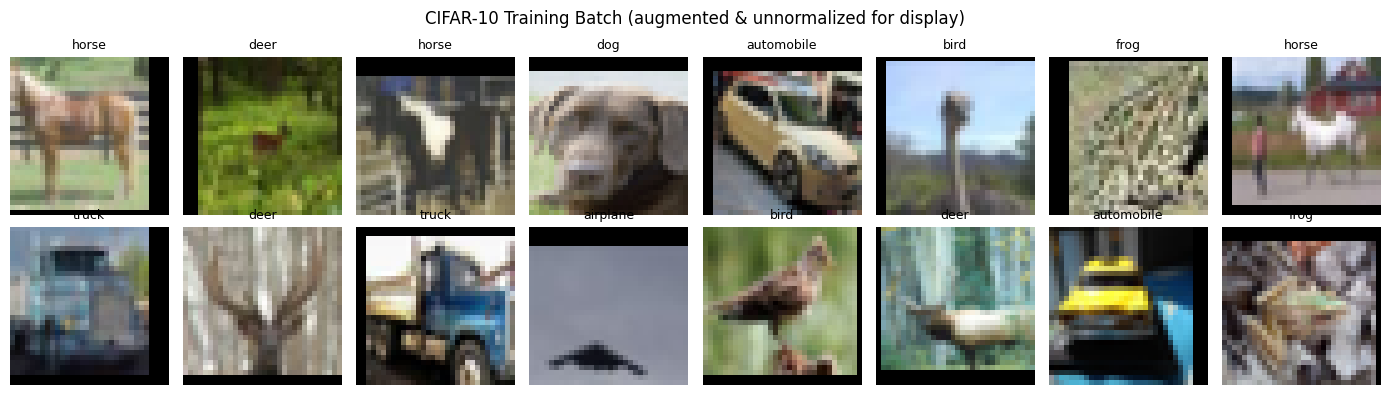

In [11]:
def unnormalize(img, mean=CIFAR_MEAN, std=CIFAR_STD):
    """Reverse normalization for display."""
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)

# Display normalized images properly
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = unnormalize(imgs[i])
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(classes[labels[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("CIFAR-10 Training Batch (augmented & unnormalized for display)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 🧪 Exercises

### Exercise 1: Augmentation gallery
Pick one CIFAR-10 image. Apply each augmentation individually (flip, crop, rotation, color jitter, erasing) 5 times. Create a 5×5 grid.

### Exercise 2: MLP on CIFAR-10
Try training your Day 11 MLP on CIFAR-10 (input_dim = 3×32×32 = 3072). What accuracy do you get? Why is it so much harder than MNIST?

### Exercise 3: Custom augmentation
Write a custom transform class that adds Gaussian noise to an image. Use it in the training pipeline.

### Exercise 4: Effect of augmentation
Train the same model with and without augmentation for 20 epochs. Plot train/val curves. Does augmentation help?

In [ ]:
# Exercise 1: Your code here

In [ ]:
# Exercise 2: Your code here

In [ ]:
# Exercise 3: Your code here

In [ ]:
# Exercise 4: Your code here

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **Image tensors** | Shape `(C, H, W)` — channels first in PyTorch |
| **CIFAR-10** | 32×32 RGB images, 10 classes — much harder than MNIST |
| **Normalization** | Subtract mean, divide by std per channel |
| **Data augmentation** | Random transforms during training only |
| **Key augmentations** | HFlip, RandomCrop(+padding), ColorJitter |
| **No augmentation on test** | Test data only gets normalization |

**Tomorrow:** We start CNNs! The convolution operation will feel natural — think of it as applying spatial filters, just like PSFs in optics! 🔬